In [3]:
pip install seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load data
customers = pd.read_csv('../data/customers.csv')
transactions = pd.read_csv('../data/transactions.csv')
products_held = pd.read_csv('../data/products_held.csv')
catalog = pd.read_csv('../data/product_catalog.csv')

print("✅ Data loaded!")
print(f"Customers:     {len(customers):,}")
print(f"Transactions:  {len(transactions):,}")
print(f"Products Held: {len(products_held):,}")
print(f"Catalog Items: {len(catalog)}")

✅ Data loaded!
Customers:     10,000
Transactions:  300,123
Products Held: 27,589
Catalog Items: 8


In [5]:
# Quick overview of each dataset
print("=" * 50)
print("CUSTOMERS")
print("=" * 50)
print(customers.head(3))
print(f"\nShape: {customers.shape}")
print(f"\nMissing values:\n{customers.isnull().sum()}")

print("\n" + "=" * 50)
print("TRANSACTIONS")
print("=" * 50)
print(transactions.head(3))
print(f"\nShape: {transactions.shape}")

print("\n" + "=" * 50)
print("PRODUCTS HELD")
print("=" * 50)
print(products_held.head(3))
print(f"\nShape: {products_held.shape}")

CUSTOMERS
  customer_id            name  age                     email         city  \
0     C_00001  Phillip Branch   22       wmalone@example.com      Amyfurt   
1     C_00002      Jacob Ward   32  josephrobert@example.com  Lake Daniel   
2     C_00003  Rhonda Gardner   23   hudsonkerri@example.org    Donnafurt   

  state  income  credit_score employment_type marital_status  tenure_months  \
0    NM   58024           651        salaried         single             95   
1    MD   75741           631  business_owner        married              5   
2    AZ   54328           649  business_owner       divorced              4   

              segment  
0  young_professional  
1  young_professional  
2  young_professional  

Shape: (10000, 12)

Missing values:
customer_id        0
name               0
age                0
email              0
city               0
state              0
income             0
credit_score       0
employment_type    0
marital_status     0
tenure_months      0


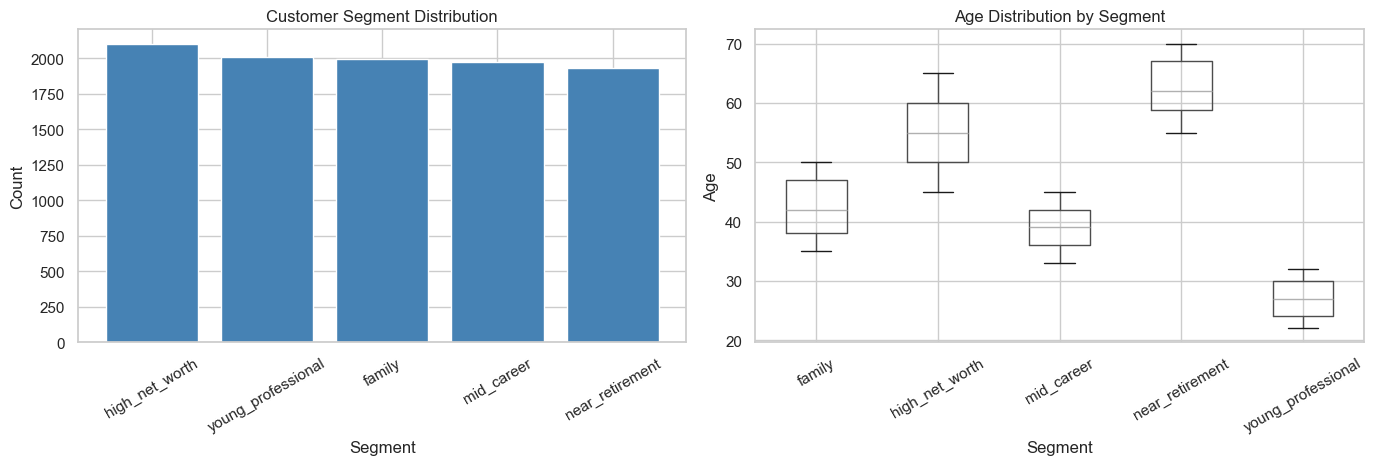

In [6]:
# How are customers distributed across segments?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment distribution
segment_counts = customers['segment'].value_counts()
axes[0].bar(segment_counts.index, segment_counts.values, color='steelblue')
axes[0].set_title('Customer Segment Distribution')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Age distribution by segment
customers.boxplot(column='age', by='segment', ax=axes[1])
axes[1].set_title('Age Distribution by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Age')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.show()

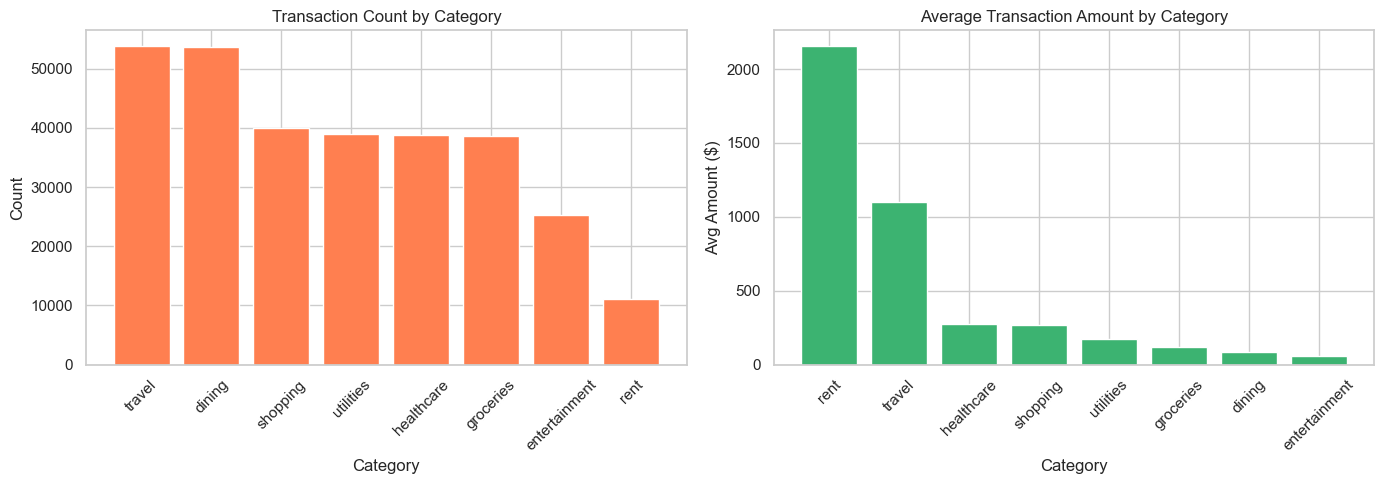

In [7]:
# Spending patterns by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction count by category
cat_counts = transactions['category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color='coral')
axes[0].set_title('Transaction Count by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Average spend by category
cat_spend = transactions.groupby('category')['amount'].mean().sort_values(ascending=False)
axes[1].bar(cat_spend.index, cat_spend.values, color='mediumseagreen')
axes[1].set_title('Average Transaction Amount by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Amount ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


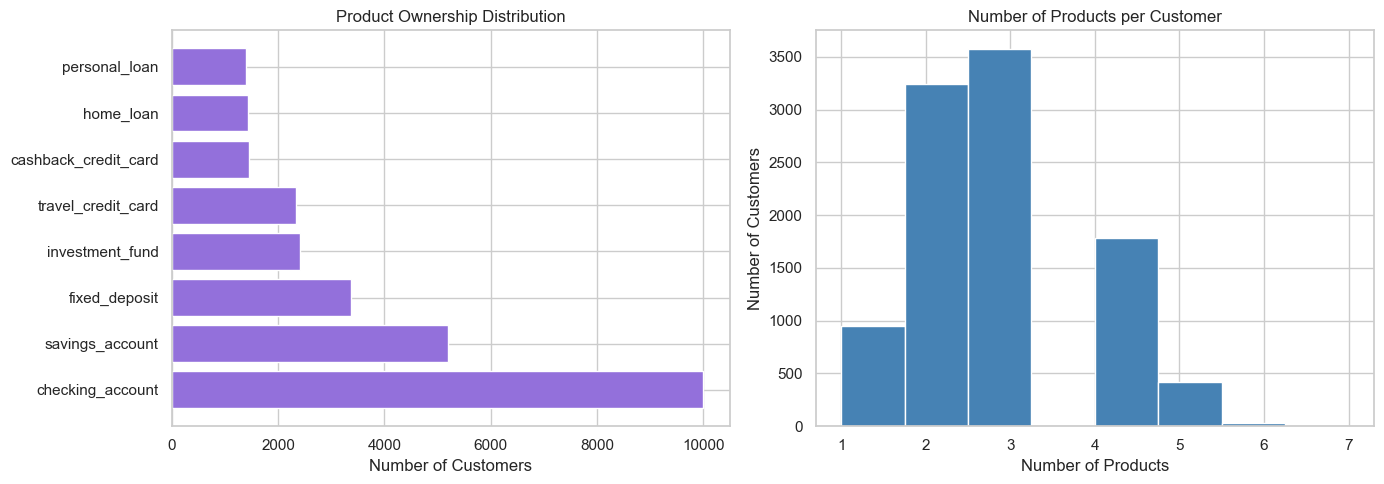

Average products per customer: 2.76
Max products per customer: 7
Min products per customer: 1


In [8]:
# Which products do customers own most?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Product ownership counts
product_counts = products_held['product_name'].value_counts()
axes[0].barh(product_counts.index, product_counts.values, color='mediumpurple')
axes[0].set_title('Product Ownership Distribution')
axes[0].set_xlabel('Number of Customers')

# Average products per customer
products_per_customer = products_held.groupby('customer_id')['product_id'].count()
axes[1].hist(products_per_customer.values, bins=8, color='steelblue', edgecolor='white')
axes[1].set_title('Number of Products per Customer')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print(f"Average products per customer: {products_per_customer.mean():.2f}")
print(f"Max products per customer: {products_per_customer.max()}")
print(f"Min products per customer: {products_per_customer.min()}")

The average customer owns only 2.76 out of 8 available products — meaning there's a 5+ product cross-sell opportunity per customer. That's the business problem we're solving.

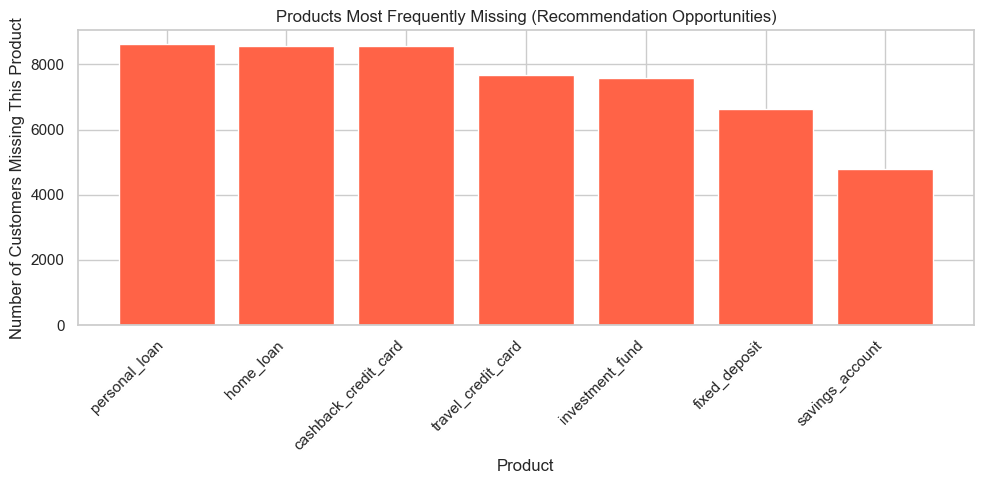


Top recommendation opportunities:
        product_name  missing_count
       personal_loan           8609
           home_loan           8565
cashback_credit_card           8548
  travel_credit_card           7664
     investment_fund           7595
       fixed_deposit           6634
     savings_account           4796


In [10]:
# What products are customers MISSING? (recommendation targets)
all_products = set(catalog['product_id'].unique())

owned_per_customer = products_held.groupby('customer_id')['product_id'].apply(set)
missing_per_customer = owned_per_customer.apply(lambda owned: all_products - owned)

# Count how often each product is missing
from collections import Counter
missing_counts = Counter()
for missing in missing_per_customer:
    missing_counts.update(missing)

missing_df = pd.DataFrame(missing_counts.items(), columns=['product_id', 'missing_count'])
missing_df = missing_df.merge(catalog[['product_id', 'product_name']], on='product_id')
missing_df = missing_df.sort_values('missing_count', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing_df['product_name'], missing_df['missing_count'], color='tomato')
plt.title('Products Most Frequently Missing (Recommendation Opportunities)')
plt.xlabel('Product')
plt.ylabel('Number of Customers Missing This Product')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop recommendation opportunities:")
print(missing_df[['product_name', 'missing_count']].to_string(index=False))